In [42]:
import pandas as pd

In [43]:
df = pd.read_csv("C:/Users/varsh/Project/Data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [45]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [46]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [47]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [48]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [49]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [50]:
df.drop(columns = ['customerID'], axis = 1, inplace = True)

In [51]:
print(f"New Dataset Shape: {df.shape}")

New Dataset Shape: (7043, 20)


In [52]:
churn_percentage = df['Churn'].value_counts(normalize=True)*100
print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [53]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize = 'index')*100
print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


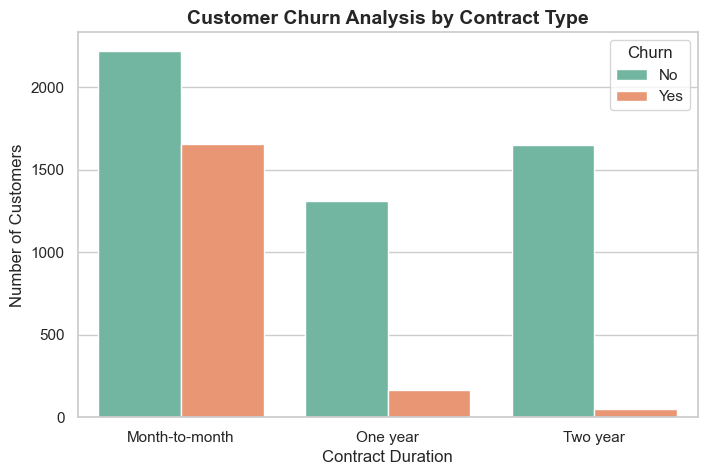

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize = (8,5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')

plt.title('Customer Churn Analysis by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Duration', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.show()

In [55]:
# Convert text targets into binary integers
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})

# Verify the changes by printing the new value distribution
print(df['Churn'].value_counts())


Churn
0    5174
1    1869
Name: count, dtype: int64


C:\Users\varsh\AppData\Local\Temp\ipykernel_30408\349579946.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})


In [56]:
#Convert all remaining text category columns into numerical dummy matrices
df_encoded = pd.get_dummies(df, columns=['Contract', 'PaymentMethod', 'InternetService'], drop_first=True)

#Look at the new structural shape and column headers of your database
print(df_encoded.shape)
print(df_encoded.columns[-5:])

(7043, 24)
Index(['PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'InternetService_Fiber optic', 'InternetService_No'],
      dtype='object')


In [57]:
#Check data types of all engineered columns
print(df_encoded.dtypes)

#Confirm there are zero remaining 'object' text columns
remaining_text = df_encoded.select_dtypes(include=['object']).columns
print(f"\nRemaining text columns: {list(remaining_text)}")

gender                                    object
SeniorCitizen                              int64
Partner                                   object
Dependents                                object
tenure                                     int64
PhoneService                              object
MultipleLines                             object
OnlineSecurity                            object
OnlineBackup                              object
DeviceProtection                          object
TechSupport                               object
StreamingTV                               object
StreamingMovies                           object
PaperlessBilling                          object
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
Contract_One year                           bool
Contract_Two year                           bool
PaymentMethod_Credit card (automatic)       bool
PaymentMethod_Electr

In [58]:
#Pass the entire dataframe through get_dummies to encode all remaining object columns
df_final = pd.get_dummies(df_encoded, drop_first=True)

#Print the final shape and data types to confirm the complete numerical conversion
print("Final Dataset Shape:", df_final.shape)
print("\nRemaining text columns:", list(df_final.select_dtypes(include=['object']).columns))

Final Dataset Shape: (7043, 31)

Remaining text columns: []


In [59]:
# Separate predictive features (X) from the target outcome label (y)
X = df_final.drop(columns=['Churn'])
y = df_final['Churn']

print("Features Matrix Shape (X):", X.shape)
print("Target Vector Shape (y):", y.shape)



Features Matrix Shape (X): (7043, 30)
Target Vector Shape (y): (7043,)


In [60]:
from sklearn.model_selection import train_test_split

#Split the dataset into 80% training and 20% testing arrays
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Print the resulting matrix dimensions to verify the split math
print(f"Training Features Matrix (X_train): {X_train.shape}")
print(f"Testing Features Matrix (X_test):   {X_test.shape}")

Training Features Matrix (X_train): (5634, 30)
Testing Features Matrix (X_test):   (1409, 30)


In [61]:
from sklearn.ensemble import RandomForestClassifier

#Initialize the model with 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

#Train the committee of decision trees on your training data
rf_model.fit(X_train, y_train)

print("Random Forest Model successfully trained!")

Random Forest Model successfully trained!


In [62]:
from sklearn.metrics import accuracy_score

#Make predictions on the hidden testing data
y_pred = rf_model.predict(X_test)

#Calculate the final accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Prediction Accuracy: {accuracy * 100:.2f}%")

Model Prediction Accuracy: 78.50%


In [64]:
from sklearn.metrics import confusion_matrix, classification_report

#Generate the raw confusion matrix counts
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix Layout:\n", cm)

#Print a detailed classification performance report
print("\nDetailed Performance Report:\n", classification_report(y_test, y_pred))
      

Confusion Matrix Layout:
 [[923 112]
 [191 183]]

Detailed Performance Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



In [65]:
import pandas as pd 
import numpy as np

#Map the relative mathematical importance weights back to their original column names
importances = rf_model.feature_importances_
feature_ranking = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_ranking = feature_ranking.sort_values(by='Importance', ascending=False)

#View the top 5 most dominant churn variables
print("Top 5 Churn Driving Variables:\n", feature_ranking.head(5))

Top 5 Churn Driving Variables:
                           Feature  Importance
3                    TotalCharges    0.195188
1                          tenure    0.172682
2                  MonthlyCharges    0.168646
7  PaymentMethod_Electronic check    0.037711
9     InternetService_Fiber optic    0.037650
